In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("master_orders.csv")
df.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,...,freight_value,payment_sequential,payment_type,payment_installments,payment_value,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,...,8.72,2.0,voucher,1.0,18.59,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,...,22.76,1.0,boleto,1.0,141.46,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,...,19.22,1.0,credit_card,3.0,179.12,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,...,8.72,1.0,credit_card,1.0,28.62,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51
4,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,...,27.36,1.0,credit_card,6.0,175.26,4.0,NaN,NaN,2017-07-27 00:00:00,2017-07-27 22:48:30


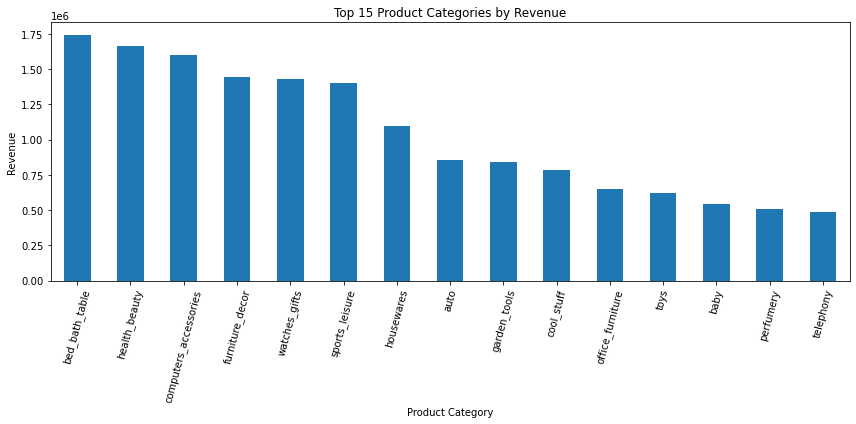

In [3]:
#1. Top 15 Product Categories by Revenue
category_sales = (
    df.groupby("product_category_name_english")["payment_value"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)
plt.figure(figsize=(12,6))
category_sales.plot(kind="bar")
plt.title("Top 15 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

1) Revenue is concentrated in a few product categories, with Bed, Bath & Table, Health & Beauty, and Computers & Accessories generating the highest sales.

2) High-performing categories contribute a significant share of total marketplace revenue, indicating strong and consistent customer demand.

3) These categories should be prioritized for inventory management, promotions, and cross-selling opportunities.

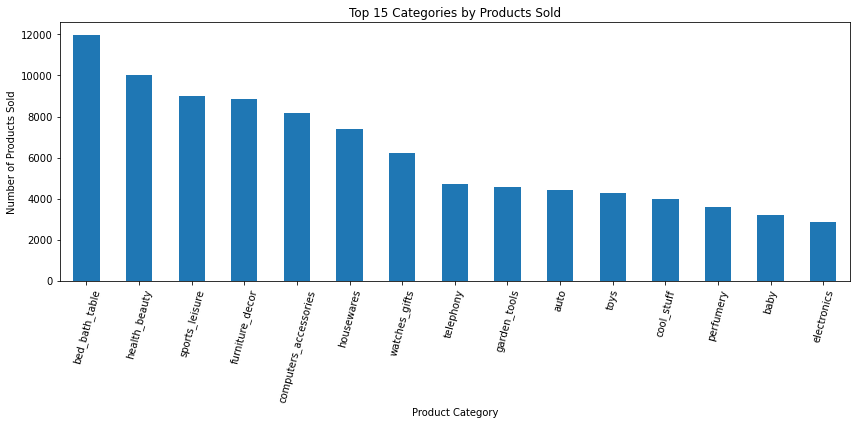

In [4]:
category_orders = (
    df.groupby("product_category_name_english")["order_item_id"]
      .count()
      .sort_values(ascending=False)
      .head(15)
      
)
plt.figure(figsize=(12,6))
category_orders.plot(kind="bar")
plt.title("Top 15 Categories by Products Sold")
plt.xlabel("Product Category")
plt.ylabel("Number of Products Sold")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

1) Bed, Bath & Table recorded the highest sales volume, followed by Health & Beauty and Sports & Leisure.

2) Categories with high sales volume are customer favorites and drive marketplace activity.

3) Comparing sales volume with revenue helps distinguish between high-volume, low-priced categories and premium categories with fewer sales.

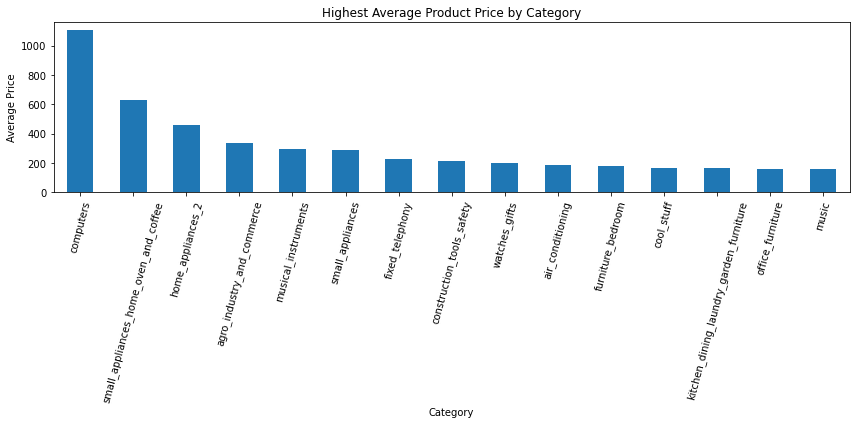

In [5]:
#3. Average Product Price by Category
avg_price = (
    df.groupby("product_category_name_english")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)
plt.figure(figsize=(12,6))
avg_price.plot(kind="bar")
plt.title("Highest Average Product Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

1) Categories such as Computers, Small Appliances (Home/Oven/Coffee), and Office Furniture have the highest average selling prices.

2) These categories generate revenue through higher-value purchases rather than large sales volumes.

3) Premium-priced categories provide opportunities for higher profit margins despite lower order counts.

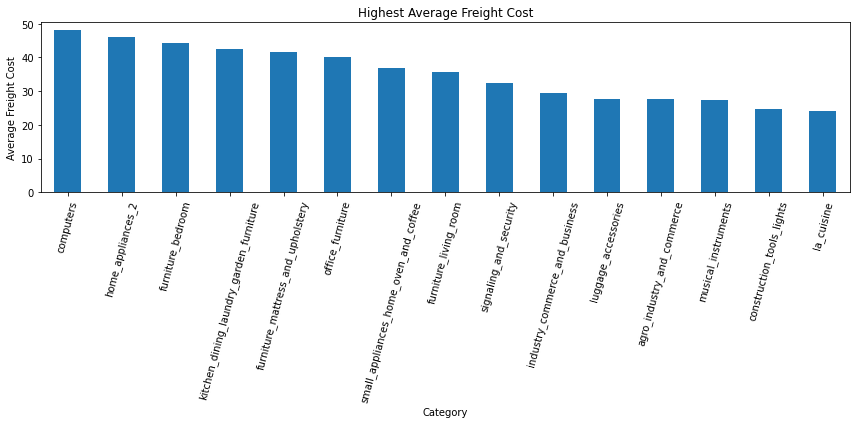

In [6]:
#4. Average Freight Cost by Category
avg_freight = (
    df.groupby("product_category_name_english")["freight_value"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)
plt.figure(figsize=(12,6))
avg_freight.plot(kind="bar")
plt.title("Highest Average Freight Cost")
plt.xlabel("Category")
plt.ylabel("Average Freight Cost")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

1) Categories including Computers, Office Furniture, and Garden Tools incur the highest average freight costs.

2) Higher freight costs are likely associated with bulky, heavy, or fragile products.

3) Optimizing shipping and packaging for these categories could improve operational efficiency and profitability.

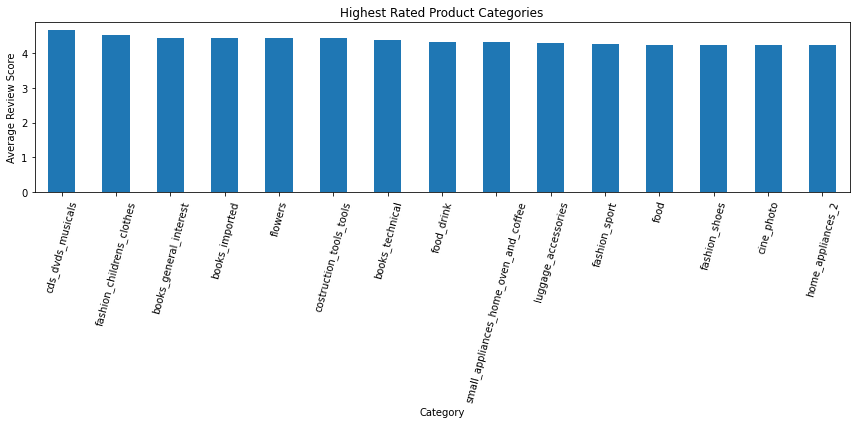

In [7]:
#5. Average Review Score by Category
review_score = (
    df.groupby("product_category_name_english")["review_score"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)
plt.figure(figsize=(12,6))
review_score.plot(kind="bar")
plt.title("Highest Rated Product Categories")
plt.xlabel("Category")
plt.ylabel("Average Review Score")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

1) Categories such as Pet Shop, Stationery, and Computers received the highest average customer ratings.

2) High review scores indicate strong customer satisfaction and consistent product quality.

3) These categories are good candidates for targeted marketing campaigns and customer retention initiatives.

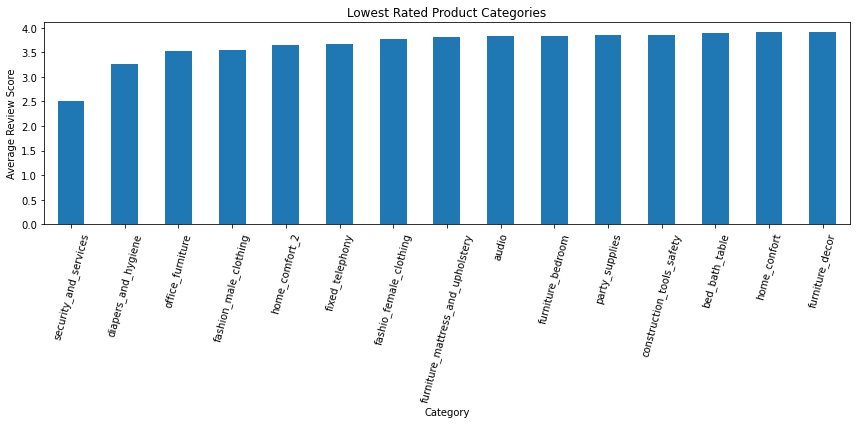

In [8]:
#6. Lowest Rated Categories
lowest_review = (
    df.groupby("product_category_name_english")["review_score"]
      .mean()
      .sort_values()
      .head(15)
)
plt.figure(figsize=(12,6))
lowest_review.plot(kind="bar")
plt.title("Lowest Rated Product Categories")
plt.xlabel("Category")
plt.ylabel("Average Review Score")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

1) Categories with lower review scores may be affected by product quality issues, delivery delays, or unmet customer expectations.

2) Office Furniture stands out with comparatively lower customer ratings among major categories.

3) Improving logistics, packaging, and product quality in these categories could enhance customer satisfaction.

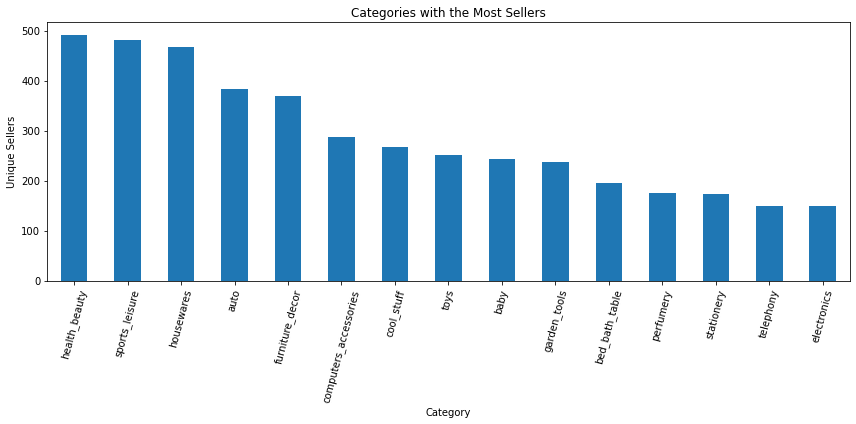

In [9]:
#7. Number of Sellers per Category
seller_count = (
    df.groupby("product_category_name_english")["seller_id"]
      .nunique()
      .sort_values(ascending=False)
      .head(15)
)
plt.figure(figsize=(12,6))
seller_count.plot(kind="bar")
plt.title("Categories with the Most Sellers")
plt.xlabel("Category")
plt.ylabel("Unique Sellers")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

1) Health & Beauty, Sports & Leisure, and Housewares have the largest number of active sellers.

2) A higher seller count reflects greater marketplace competition and product variety.

3) Categories with fewer sellers but strong revenue may offer attractive opportunities for market expansion.

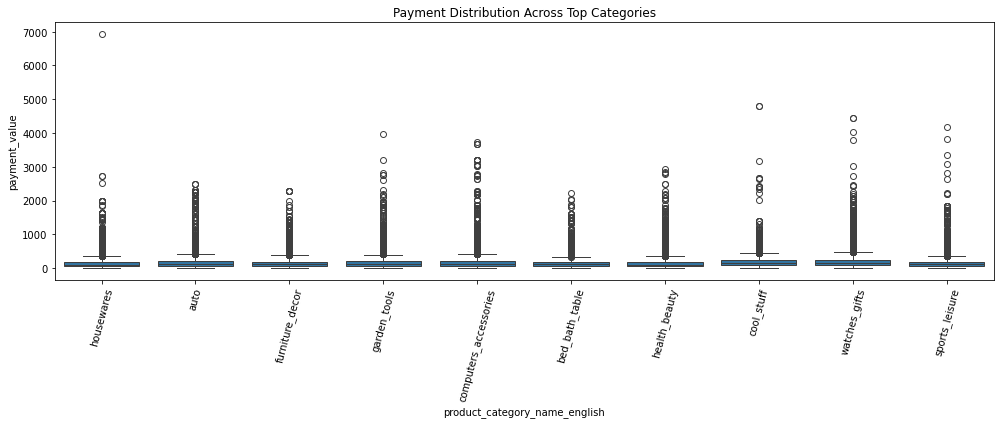

In [10]:
#8. Payment Value Distribution by Top Categories
top10 = (
    df.groupby("product_category_name_english")["payment_value"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)
plt.figure(figsize=(14,6))
sns.boxplot(
    data=df[df["product_category_name_english"].isin(top10)],
    x="product_category_name_english",
    y="payment_value"
)
plt.xticks(rotation=75)
plt.title("Payment Distribution Across Top Categories")
plt.tight_layout()
plt.show()

1) Payment values vary considerably across product categories, indicating differences in customer spending behavior.

2) Premium categories exhibit wider distributions and more high-value outliers, reflecting expensive purchases.

3) Categories with narrower distributions show more consistent spending patterns.

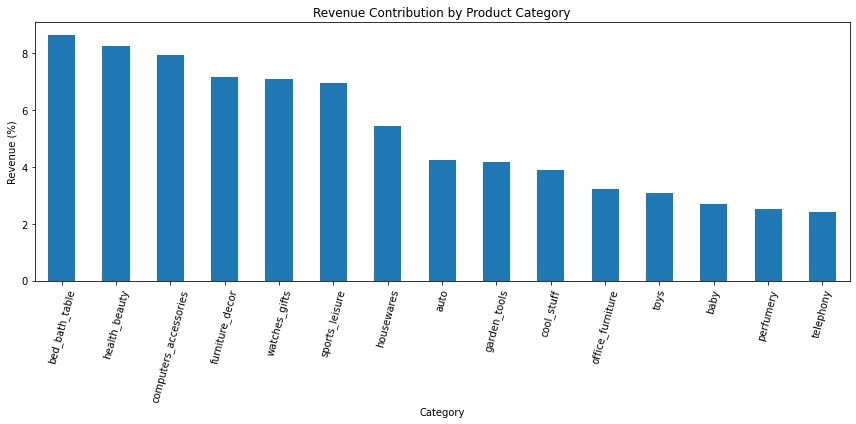

In [11]:
#9. Revenue Contribution (%)
revenue = (
    df.groupby("product_category_name_english")["payment_value"]
      .sum()
      .sort_values(ascending=False)
)

revenue_pct = (revenue / revenue.sum() * 100).head(15)
plt.figure(figsize=(12,6))
revenue_pct.plot(kind="bar")
plt.title("Revenue Contribution by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (%)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

1) A small number of product categories contribute a disproportionately large share of total revenue, illustrating the Pareto (80/20) principle.

2) Concentrating business strategies on these key categories can maximize revenue growth.

3) Lower-contributing categories may require targeted marketing or product assortment improvements.

In [12]:
#10. Product Category Performance Dashboard
category_summary = (
    df.groupby("product_category_name_english")
      .agg(
          Revenue=("payment_value","sum"),
          Orders=("order_item_id","count"),
          Avg_Price=("price","mean"),
          Avg_Freight=("freight_value","mean"),
          Avg_Review=("review_score","mean"),
          Sellers=("seller_id","nunique")
      )
      .sort_values("Revenue",ascending=False)
)
category_summary.head(20)

,Revenue,Orders,Avg_Price,Avg_Freight,Avg_Review,Sellers
product_category_name_english,,,,,,
bed_bath_table,1743998.80,11988,92.363121,18.386130,3.890605,196
health_beauty,1662963.59,10032,129.779503,18.884548,4.137026,492
computers_accessories,1599481.06,8150,116.571005,18.933539,3.936089,287
furniture_decor,1443963.61,8832,87.420309,20.750798,3.912158,370
watches_gifts,1430553.48,6213,201.886842,16.823216,4.017692,101
sports_leisure,1400223.07,9004,114.349609,19.501774,4.107470,481
housewares,1097900.09,7380,90.634274,20.967827,4.060428,468
auto,855095.68,4400,140.544432,21.826466,4.064279,383
garden_tools,840721.59,4590,113.175017,23.074941,4.023914,237


1) The dashboard provides a consolidated view of category performance across revenue, sales volume, pricing, freight cost, customer reviews, and seller participation.

2) It enables easy identification of high-performing categories as well as categories requiring operational improvements.

3) Combining multiple performance indicators supports more informed business decisions than evaluating a single metric alone.

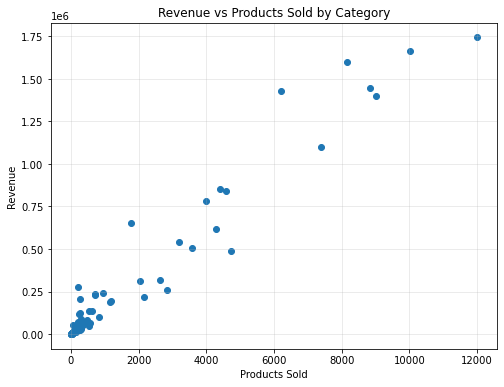

In [13]:
#11.Revenue vs Number of Products Sold
summary = (
    df.groupby("product_category_name_english")
      .agg(
          Revenue=("payment_value","sum"),
          Orders=("order_item_id","count")
      )
)
plt.figure(figsize=(8,6))
plt.scatter(
    summary["Orders"],
    summary["Revenue"]
)
plt.xlabel("Products Sold")
plt.ylabel("Revenue")
plt.title("Revenue vs Products Sold by Category")
plt.grid(alpha=0.3)
plt.show()

1) The scatter plot highlights the relationship between sales volume and revenue across product categories.

2) Categories in the upper-right quadrant represent high-performing products with both strong sales and high revenue.

3) Categories with high revenue but relatively low sales indicate premium-priced products, while categories with high sales but moderate revenue reflect volume-driven business models.

4) This analysis helps identify strategic categories for growth, pricing optimization, and targeted marketing initiatives.

The analysis revealed that Bed Bath Table is the largest revenue-generating category due to high sales volume, while Computers and Watches & Gifts generate strong revenue through higher-priced products. Health & Beauty and Sports & Leisure combine high revenue with strong customer satisfaction, making them key strategic categories. Office Furniture stands out as an area for improvement because it has the highest freight costs and the lowest average review score, indicating potential logistics and customer experience challenges. Additionally, categories such as Computers have relatively few sellers but high average prices, suggesting opportunities for marketplace expansion and premium product strategies.